In [17]:
from pathlib import Path
import sys

import lightning as L
import torch
import yaml

torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True

sys.path.append(str(Path("..").resolve()))
from pipeline import Pipeline  # noqa: E402

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from pathlib import Path
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from pathlib import Path
import yaml
import json
import torch
import lightning as L
from datetime import datetime


In [20]:

def run_experiment(
    config_name: str,
    config_dir: str = "../configs",
    runs_dir: str = "runs",
):
    """
    Runs full training + evaluation pipeline.

    Returns:
        metrics (dict)
        probs (torch.Tensor)
        targets (torch.Tensor)
        run_dir (Path)
    """

    # --- load config ---
    config_path = Path(config_dir) / f"{config_name}.yaml"

    if not config_path.exists():
        raise FileNotFoundError(f"Config not found: {config_path}")

    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    print(f"[INFO] Loaded config: {config_path.resolve()}")

    # --- reproducibility ---
    L.seed_everything(
        config["training"].get("seed", 42),
        workers=True
    )

    # --- create run directory ---
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    run_dir = Path(runs_dir) / f"{timestamp}_{config_name}"
    run_dir.mkdir(parents=True, exist_ok=True)

    print(f"[INFO] Run directory: {run_dir.resolve()}")

    # --- save config snapshot ---
    with open(run_dir / "config.yaml", "w") as f:
        yaml.safe_dump(config, f, sort_keys=False)

    # --- run pipeline ---
    pipeline = Pipeline(config)
    outputs = pipeline.run()

    metrics = outputs["metrics"]
    probs = outputs["probs"]
    targets = outputs["targets"]

    # --- fix metrics format safely ---
    if isinstance(metrics, list) and len(metrics) > 0:
        metrics = metrics[0]

    metrics = {
        k: float(v) if torch.is_tensor(v) else v
        for k, v in metrics.items()
    }

    # --- save metrics ---
    with open(run_dir / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    # --- save tensors ---
    torch.save(probs, run_dir / "probs.pt")
    torch.save(targets, run_dir / "targets.pt")

    # --- optional: save model weights if available ---
    if hasattr(pipeline, "lightning_model"):
        try:
            torch.save(
                pipeline.lightning_model.model.state_dict(),
                run_dir / "model_state_dict.pt"
            )
        except Exception as e:
            print(f"[WARN] Could not save model weights: {e}")

    print("\n[INFO] Run completed")
    print(f"[INFO] Saved to: {run_dir.resolve()}")

    return metrics, probs, targets, run_dir

In [21]:
classes = {
    0: "HToBB",
    1: "HToCC",
    2: "HToGG",
    3: "HToWW2Q1L",
    4: "HToWW4Q",
    5: "TTBar",
    6: "TTBarLep",
    7: "WToQQ",
    8: "ZJetsToNuNu",
    9: "ZToQQ",
}

In [26]:
metrics, probs, targets, run_dir = run_experiment("transformer_model")

print(metrics)
print(probs.shape, targets.shape)

[rank: 0] Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[INFO] Loaded config: /gpfs/home4/scur0118/ML_project/configs/transformer_model.yaml
[INFO] Run directory: /gpfs/home4/scur0118/ML_project/notebooks/runs/2026-05-23_15-23-57_transformer_model

Run directory:
/gpfs/home4/scur0118/ML_project/notebooks/runs/ParticleTransformer/20260523_152357

classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type                | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model   | ParticleTransformer | 863 K  | train | 0    
1 | loss_fn | CrossEntropyLoss    | 0      | train | 0    
----------------------------------------------------------------
863 K     Trainable params
0         Non-trainable params
863 K     Total params
3.452     Total estimated model params size (MB)
64        Modules in train mode
0         Modules in eval mode
0         Total Flops



Dataset sizes:
Train: 4014080
Val:   860160
Test:  860160
Epoch 49: 100%|██████████| 7840/7840 [02:47<00:00, 46.88it/s, v_num=0, train_loss_step=0.261, train_acc_step=0.920, val_loss=0.867, val_acc=0.694, train_loss_epoch=0.681, train_acc_epoch=0.757] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 7840/7840 [02:47<00:00, 46.85it/s, v_num=0, train_loss_step=0.261, train_acc_step=0.920, val_loss=0.867, val_acc=0.694, train_loss_epoch=0.681, train_acc_epoch=0.757]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 1680/1680 [00:18<00:00, 92.58it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.7211937308311462
        test_loss           0.7771424055099487
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Saved:
runs/ParticleTransformer/20260523_152357/model.pt
runs/ParticleTransformer/20260523_152357/probs.pt
runs/ParticleTransformer/20260523_152357/targets.pt
runs/ParticleTransformer/20260523_152357/metrics.json
runs/ParticleTransformer/20260523_152357/logs

[INFO] Run completed
[INFO] Saved to: /gpfs/home4/scur0118/ML_project/notebooks/runs/2026-05-23_15-23-57_transformer_model
{'test_loss': 0.7771424055099487, 'test_a

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def plot_training_curves(run_dir: str | Path, smooth_window: int = 1):
    """
    Plots training/validation loss and accuracy vs epoch
    from Lightning CSVLogger output.

    Parameters
    ----------
    run_dir : str | Path
        Path to the run directory (the one created by Pipeline).
    smooth_window : int
        Moving average window (1 = no smoothing).
    """

    run_dir = Path(run_dir)

    metrics_path = run_dir / "logs" / "version_0" / "metrics.csv"

    if not metrics_path.exists():
        raise FileNotFoundError(f"No metrics.csv found at {metrics_path}")

    df = pd.read_csv(metrics_path)

    # Lightning logs multiple rows per epoch; we keep epoch-level metrics only
    df = df.sort_values("epoch")

    def smooth(series):
        if smooth_window <= 1:
            return series
        return series.rolling(smooth_window, min_periods=1).mean()

    # -------------------------
    # Loss plot
    # -------------------------
    plt.figure(figsize=(8, 5))

    if "train_loss_epoch" in df.columns:
        plt.plot(
            df["epoch"],
            smooth(df["train_loss_epoch"]),
            label="train loss",
        )

    if "val_loss" in df.columns:
        plt.plot(
            df["epoch"],
            smooth(df["val_loss"]),
            label="val loss",
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------
    # Accuracy plot
    # -------------------------
    plt.figure(figsize=(8, 5))

    if "train_acc_epoch" in df.columns:
        plt.plot(
            df["epoch"],
            smooth(df["train_acc_epoch"]),
            label="train acc",
        )

    if "val_acc" in df.columns:
        plt.plot(
            df["epoch"],
            smooth(df["val_acc"]),
            label="val acc",
        )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

[INFO] Using run: runs/2026-05-22_20-52-14_transformer_model

Accuracy: 0.6798


/scratch-local/scur0118.23037489/ipykernel_3215612/1414545044.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


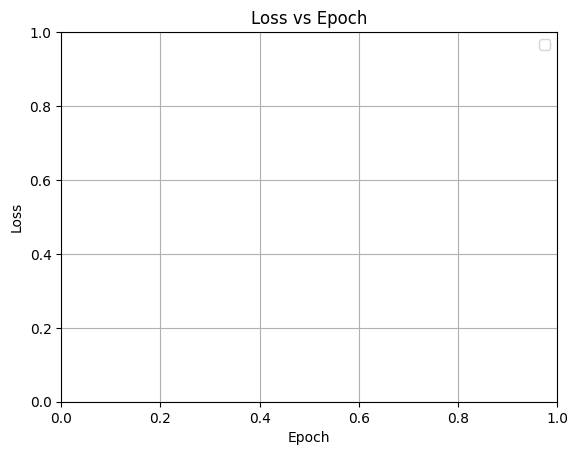

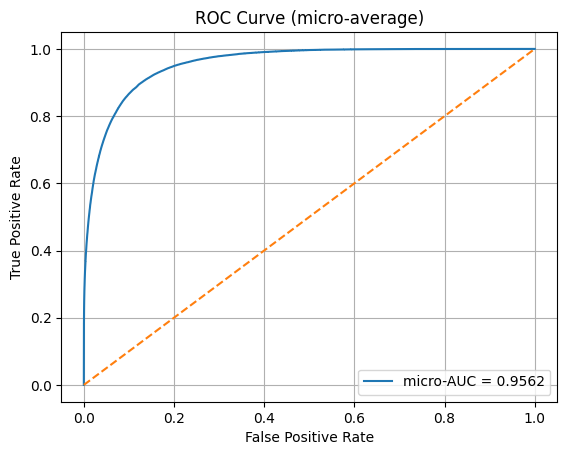

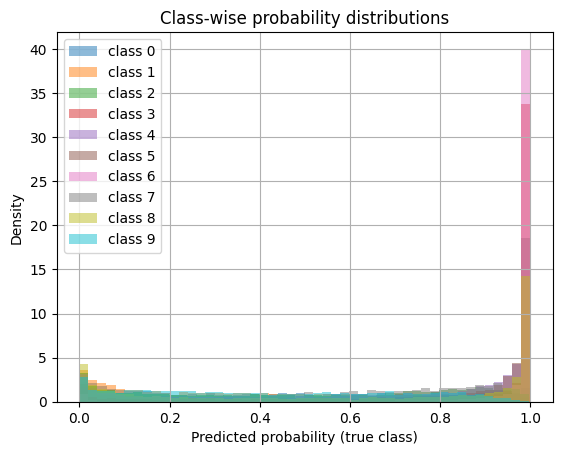

{'accuracy': np.float64(0.6797991071428572),
 'run_dir': 'runs/2026-05-22_20-52-14_transformer_model'}

In [8]:
analyze_latest_run("transformer_model")

In [ ]:
metrics, probs, targets, run_dir = run_experiment("jet_model")

print(metrics)
print(probs.shape, targets.shape)

[rank: 0] Seed set to 42
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/scur0118/ML_project/.venv/lib64/python3.11/sit ...
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[INFO] Loaded config: /gpfs/home4/scur0118/ML_project/configs/jet_model.yaml
[INFO] Run directory: /gpfs/home4/scur0118/ML_project/notebooks/runs/2026-05-22_21-14-08_jet_model

classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


Exception ignored in: <function ReadOnlyFile.__del__ at 0x147351819b20>
Traceback (most recent call last):
  File "/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/uproot/reading.py", line 656, in __del__
    def __del__(self):

KeyboardInterrupt: 
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | JetOnlyModel     | 52.1 K | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-


Dataset sizes:
Train: 250880
Val:   53760
Test:  53760
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/scur0118/ML_project/.venv/lib64/python3.11/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 0:  18%|█▊        | 89/490 [00:02<00:09, 44.23it/s, v_num=84, train_loss_step=2.080, train_acc_step=0.289] 

In [8]:
metrics, probs, targets, run_dir = run_experiment("particle_model")

print(metrics)
print(probs.shape, targets.shape)

[rank: 0] Seed set to 42


[INFO] Loaded config: /gpfs/home4/scur0118/ML_project/configs/particle_model.yaml
[INFO] Run directory: /gpfs/home4/scur0118/ML_project/notebooks/runs/2026-05-22_16-24-19_particle_model


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type              | Params | Mode  | FLOPs
--------------------------------------------------------------
0 | model   | ParticleOnlyModel | 52.1 K | train | 0    
1 | loss_fn | CrossEntropyLoss  | 0      | train | 0    
--------------------------------------------------------------
52.1 K    Trainable params
0         Non-trainable params
52.1 K    Total params
0.208     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
0         Total Flops



Dataset sizes:
Train: 250880
Val:   53760
Test:  53760
Epoch 99: 100%|██████████| 490/490 [00:08<00:00, 56.52it/s, v_num=74, train_loss_step=0.974, train_acc_step=0.672, val_loss=1.150, val_acc=0.568, train_loss_epoch=1.080, train_acc_epoch=0.608]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 490/490 [00:08<00:00, 56.21it/s, v_num=74, train_loss_step=0.974, train_acc_step=0.672, val_loss=1.150, val_acc=0.568, train_loss_epoch=1.080, train_acc_epoch=0.608]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 105/105 [00:00<00:00, 254.77it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.5925223231315613
        test_loss           1.0628350973129272
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

[INFO] Run completed
[INFO] Saved to: /gpfs/home4/scur0118/ML_project/notebooks/runs/2026-05-22_16-24-19_particle_model
{'test_loss': 1.0628350973129272, 'test_acc': 0.5925223231315613}
torch.Size([53760, 10]) torch.Size([53760])


In [9]:
metrics, probs, targets, run_dir = run_experiment("mixed_model")

print(metrics)
print(probs.shape, targets.shape)

[rank: 0] Seed set to 42


[INFO] Loaded config: /gpfs/home4/scur0118/ML_project/configs/mixed_model.yaml
[INFO] Run directory: /gpfs/home4/scur0118/ML_project/notebooks/runs/2026-05-22_16-38-56_mixed_model


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model   | HybridModel      | 86.3 K | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
86.3 K    Trainable params
0         Non-trainable params
86.3 K    Total params
0.345     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode
0         Total Flops



Dataset sizes:
Train: 250880
Val:   53760
Test:  53760
Epoch 99: 100%|██████████| 490/490 [00:08<00:00, 56.56it/s, v_num=75, train_loss_step=0.783, train_acc_step=0.721, val_loss=0.955, val_acc=0.649, train_loss_epoch=0.888, train_acc_epoch=0.681]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 490/490 [00:08<00:00, 56.22it/s, v_num=75, train_loss_step=0.783, train_acc_step=0.721, val_loss=0.955, val_acc=0.649, train_loss_epoch=0.888, train_acc_epoch=0.681]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 105/105 [00:00<00:00, 251.95it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6751487851142883
        test_loss           0.8823968172073364
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

[INFO] Run completed
[INFO] Saved to: /gpfs/home4/scur0118/ML_project/notebooks/runs/2026-05-22_16-38-56_mixed_model
{'test_loss': 0.8823968172073364, 'test_acc': 0.6751487851142883}
torch.Size([53760, 10]) torch.Size([53760])


In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def run_and_plot_all():
    """
    Runs 4 configs and plots validation accuracy vs epoch.
    Requires:
        - run_experiment(config_name) already defined
        - CSVLogger enabled in Pipeline
    """

    config_names = [
        "transformer_model",
        "jet_model",
        "particle_model",
        "mixed_model",
    ]

    # --------------------------------------------------
    # run experiments
    # --------------------------------------------------
    run_dirs = {}

    for name in config_names:
        print(f"\n[RUNNING] {name}\n")

        metrics, probs, targets, run_dir = run_experiment(name)
        run_dirs[name] = Path(run_dir)

    # --------------------------------------------------
    # helper: load curve from CSVLogger
    # --------------------------------------------------
    def load_val_acc(run_dir: Path):
        csv_path = run_dir / "logs" / "version_0" / "metrics.csv"

        if not csv_path.exists():
            raise FileNotFoundError(f"Missing: {csv_path}")

        df = pd.read_csv(csv_path)
        df = df.sort_values("epoch")

        if "val_acc" not in df.columns:
            raise KeyError(f"val_acc not found in {csv_path.columns}")

        return df["epoch"].values, df["val_acc"].values

    # --------------------------------------------------
    # plot
    # --------------------------------------------------
    plt.figure(figsize=(10, 6))

    for name, run_dir in run_dirs.items():
        epochs, acc = load_val_acc(run_dir)

        plt.plot(
            epochs,
            acc,
            marker="o",
            label=name,
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("Validation Accuracy vs Epoch")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# run everything
run_and_plot_all()

[rank: 0] Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



[RUNNING] transformer_model

[INFO] Loaded config: /gpfs/home4/scur0118/ML_project/configs/transformer_model.yaml
[INFO] Run directory: /gpfs/home4/scur0118/ML_project/notebooks/runs/2026-05-22_22-15-35_transformer_model

Run directory:
/gpfs/home4/scur0118/ML_project/notebooks/runs/ParticleTransformer/20260522_221535

classes:
0 HToBB
1 HToCC
2 HToGG
3 HToWW2Q1L
4 HToWW4Q
5 TTBar
6 TTBarLep
7 WToQQ
8 ZJetsToNuNu
9 ZToQQ


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type                | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model   | ParticleTransformer | 466 K  | train | 0    
1 | loss_fn | CrossEntropyLoss    | 0      | train | 0    
----------------------------------------------------------------
466 K     Trainable params
0         Non-trainable params
466 K     Total params
1.866     Total estimated model params size (MB)
44        Modules in train mode
0         Modules in eval mode
0         Total Flops



Dataset sizes:
Train: 250880
Val:   53760
Test:  53760
Epoch 99: 100%|██████████| 490/490 [00:11<00:00, 43.21it/s, v_num=0, train_loss_step=0.553, train_acc_step=0.812, val_loss=1.040, val_acc=0.652, train_loss_epoch=0.631, train_acc_epoch=0.766]

`Trainer.fit` stopped: `max_epochs=100` reached.


...

Epoch 99: 100%|██████████| 490/490 [00:09<00:00, 50.69it/s, v_num=0, train_loss_step=0.774, train_acc_step=0.732, val_loss=0.954, val_acc=0.649, train_loss_epoch=0.887, train_acc_epoch=0.680]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 105/105 [00:00<00:00, 252.82it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6756138205528259
        test_loss           0.8812022805213928
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Saved:
runs/HybridModel/20260522_230550/model.pt
runs/HybridModel/20260522_230550/probs.pt
runs/HybridModel/20260522_230550/targets.pt
runs/HybridModel/20260522_230550/metrics.json
runs/HybridModel/20260522_230550/logs

[INFO] Run completed
[INFO] Saved to: /gpfs/home4/scur0118/ML_project/notebooks/runs/2026-05-22_23-05-50_mixed_model


FileNotFoundError: Missing: runs/2026-05-22_22-15-35_transformer_model/logs/version_0/metrics.csv

<Figure size 1000x600 with 0 Axes>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df_trans = pd.read_csv("runs/ParticleTransformer/20260522_221535/logs/version_0/metrics.csv")
df_trans = df_trans.groupby("epoch").mean().reset_index()

df_jet =  pd.read_csv("runs/JetOnlyModel/20260522_223444/logs/version_0/metrics.csv") 
df_jet = df_jet.groupby("epoch").mean().reset_index()

df_part = pd.read_csv("runs/ParticleOnlyModel/20260522_225007/logs/version_0/metrics.csv")
df_part = df_part.groupby("epoch").mean().reset_index()

df_mix = pd.read_csv("runs/HybridModel/20260522_230550/logs/version_0/metrics.csv")
df_mix = df_mix.groupby("epoch").mean().reset_index()


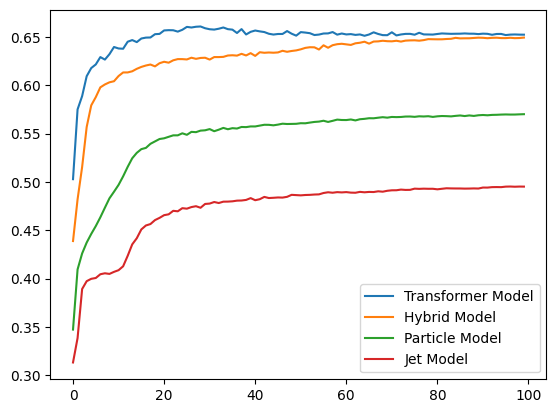

In [ ]:
plt.plot(df_trans.epoch, df_trans.val_acc, label = "Transformer Model")
plt.plot(df_mix.epoch, df_mix.val_acc, label = "Hybrid Model")
plt.plot(df_part.epoch, df_part.val_acc, label = "Particle Model")
plt.plot(df_jet.epoch, df_jet.val_acc, label = "Jet Model")
plt.legend()

In [33]:
df_trans = pd.read_csv("runs/ParticleTransformer/20260523_152357/logs/version_0/metrics.csv")
df_trans = df_trans.groupby("epoch").mean().reset_index()

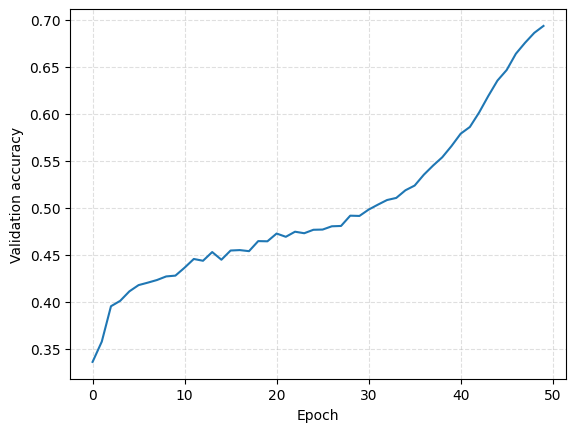

In [36]:
plt.plot(df_trans.epoch, df_trans.val_acc, label = "Transformer Model")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.grid(alpha = 0.4, ls = "--")
